Checking the GPU availablity. The selected model was Qwen. The GPU used is NVIDIA A100-SXM4-80GB. The GPU at indexed zero is used.

In [ ]:
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    raise SystemError("No GPU")


CUDA available : True
GPU            : NVIDIA A100-SXM4-80GB
GPU Memory     : 85.09 GB


Installing all the python library required for the Qwen model to train.
Hugging face transformer 4.49.0 is used load the model.

qwen-vl-utils - specify utilities handles image processing specific to qwen vision model.

peft - Parameter efficient find tuning enables LoRA so fine tune only a small fraction of model not all the billions parameters.

pillow torchvision - image loading, resizing and preprocessing.

In [ ]:
import subprocess, sys

cmds = [
    "pip install -q transformers==4.49.0",
    "pip install -q qwen-vl-utils",
    "pip install -q peft accelerate bitsandbytes",
    "pip install -q datasets pillow torchvision",
]
for cmd in cmds:
    subprocess.run(cmd.split(), check=True)

print("\nDone")


Done


 logged into Hugging face hub using secret token to access private model and the dataset.



In [ ]:
try:
    from google.colab import userdata
    from huggingface_hub import login
    token = userdata.get("HF_TOKEN")
    if token:
        login(token=token)
        print("Logged in")
    else:
        print("Anonymous access")
except Exception:
    print("Anonymous access")

Logged in


load the dataset and flattens it to individual question and answer pairs.pairs are ready for model training.

parse_qa_pairs() converts raw, inconsistent string fields from the dataset into clean (question, answer) tuples.

It handles three inconsistencies in the dataset — mixed serialization formats (JSON vs Python literals), varying data shapes (list vs single dict), and inconsistent key names ("question"/"Q"/"q").

At every step it fails gracefully, skipping malformed rows rather than crashing the pipeline.

The end result is that 100,000 raw document rows are reliably expanded into 300,000 clean training examples ready for model fine-tuning.

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import json, ast, torch

print("loading dataset")
dataset = load_dataset(
    "sujet-ai/Sujet-Finance-QA-Vision-100k",
    split="train",
    trust_remote_code=True,
)
print(f"loaded {len(dataset):,} documents")
print("raw qa_pairs sample:", str(dataset[0]["qa_pairs"])[:300])


def parse_qa_pairs(qa_str):
    if not qa_str:
        return []
    try:
        pairs = json.loads(qa_str)
    except Exception:
        try:
            pairs = ast.literal_eval(qa_str)
        except Exception:
            return []
    if isinstance(pairs, dict):
        pairs = [pairs]
    if not isinstance(pairs, list):
        return []
    results = []
    for p in pairs:
        if not isinstance(p, dict):
            continue
        q = (p.get("question") or p.get("Q") or p.get("q") or "").strip()
        a = (p.get("answer")   or p.get("A") or p.get("a") or "").strip()
        if q and a:
            results.append((q, a))
    return results


flat_images, flat_questions, flat_answers = [], [], []
for row in dataset:
    for q, a in parse_qa_pairs(row["qa_pairs"]):
        flat_images.append(row["image"])
        flat_questions.append(q)
        flat_answers.append(a)

print(f"total number of Question and answers pairs: {len(flat_questions):,}")
print(f"sample Question: {flat_questions[0][:120]}")
print(f"sample Answer: {flat_answers[0][:120]}")

loads the Qwen2-VL 2B vision-language model and its accompanying processor from HuggingFace into GPU memory, configured for efficient training.


The processor is initialized with pixel boundary constraints (128×28×28 to 256×28×28) that control how financial document images are resized before being fed to the model.

 The model itself is loaded in bfloat16 precision with device_map="auto", which halves memory consumption compared to full float32 while letting HuggingFace automatically distribute layers across available GPUs.


In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"
DEVICE     = "cuda"
DTYPE      = torch.bfloat16

processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    min_pixels=128 * 28 * 28,
    max_pixels=256 * 28 * 28,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto",
)
print(f"parameters: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")
print(f"GPU   : {torch.cuda.memory_allocated()/1e9:.2f} GB used")

wraping the loaded Qwen2-VL model with LoRA (Low-Rank Adaptation), a parameter-efficient fine-tuning technique that avoids updating all 2 billion weights during training.


Instead of modifying the original model weights, LoRA injects small trainable rank-8 matrices alongside every linear layer — controlled by r=8 for matrix size and lora_alpha=16 for scaling strength.

The target_modules="all-linear" setting applies LoRA adapters across every linear layer in the network, while lora_dropout=0.05 adds light regularization to prevent overfitting on the finance dataset.

instead of training ~2B parameters, model.print_trainable_parameters() will reveal that only 1-5% of parameters are actually trainable, reducing GPU memory and training time massively while still adapting the model effectively to financial DocVQA.

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

model = get_peft_model(model, LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules="all-linear", #
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
))
model.print_trainable_parameters()

trainable params: 14,610,432 || all params: 2,223,596,032 || trainable%: 0.6571


This cell builds the complete data pipeline that feeds financial document images and Q&A pairs into the Qwen2-VL model during training.


The FinanceVQADataset class is a standard PyTorch Dataset wrapper that holds the flattened images, questions, and answers, converting raw arrays to RGB PIL images on the fly.


The dataset is split into 3,000 training and 200 validation samples using a fixed random seed for reproducibility.

The most complex piece is collate_fn, which runs for every batch and transforms raw (image, question, answer) triples into the exact tensor format Qwen2-VL expects — including tokenization, image encoding, and chat template formatting.

Inside collate_fn, messages are structured in Qwen's chat format with a system-style prompt establishing the model as a financial document expert, followed by the question and answer.

A critical training detail is label masking — the prompt tokens are set to -100 so the model only learns to predict the answer tokens, not repeat the question back.

All sequences in a batch are padded to the same length and moved to GPU, while pixel values are cast to bfloat16 to match the model's precision.

The DataLoader wraps both datasets with batch_size=1 — chosen because vision-language model inputs are memory-heavy due to image patch tensors.

Finally, a sanity check runs one forward pass through the model before training begins, confirming the entire pipeline works end-to-end and printing an initial loss value to verify gradients will flow correctly.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import random

BATCH_SIZE    = 1
TRAIN_SAMPLES = 3000
VAL_SAMPLES   = 200
SEED          = 42
MAX_SEQ_LEN   = 768


class FinanceVQADataset(Dataset):
    def __init__(self, images, questions, answers):
        self.images    = images
        self.questions = questions
        self.answers   = answers

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        return {
            "image":    img.convert("RGB"),
            "question": self.questions[idx],
            "answer":   self.answers[idx],
        }


def make_messages(question, answer=None):

    user_content = [
        {"type": "image", "image": "placeholder"},
        {"type": "text",  "text": (
            "you are a financial document expert. "
            "answer the question based on the document image.\n\n"
            f"question: {question}"
        )},
    ]
    msgs = [{"role": "user", "content": user_content}]
    if answer is not None:
        msgs.append({"role": "assistant", "content": answer})
    return msgs


def collate_fn(batch):

    all_input_ids      = []
    all_attention_mask = []
    all_labels         = []
    all_pixel_values   = []
    all_image_grid_thw = []

    for item in batch:
        image    = item["image"]
        question = item["question"]
        answer   = item["answer"]


        from qwen_vl_utils import process_vision_info

        full_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text",  "text": (
                        "you are a financial document expert. "
                        "answer the question based on the document image.\n\n"
                        f"question: {question}"
                    )},
                ],
            },
            {"role": "assistant", "content": answer},
        ]

        prompt_messages = full_messages[:-1]


        full_text   = processor.apply_chat_template(full_messages,   tokenize=False, add_generation_prompt=False)
        prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)


        image_inputs, _ = process_vision_info(full_messages)


        enc = processor(
            text=[full_text],
            images=image_inputs,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=MAX_SEQ_LEN,
        )


        prompt_ids = processor.tokenizer(
            prompt_text,
            return_tensors="pt",
            add_special_tokens=False,
        ).input_ids

        input_ids = enc["input_ids"][0]
        labels    = input_ids.clone()


        prompt_len = min(len(prompt_ids[0]), len(labels))
        labels[:prompt_len] = -100

        all_input_ids.append(input_ids)
        all_attention_mask.append(enc["attention_mask"][0])
        all_labels.append(labels)
        all_pixel_values.append(enc["pixel_values"])
        all_image_grid_thw.append(enc["image_grid_thw"])


    max_len = max(x.shape[0] for x in all_input_ids)
    pad_id  = processor.tokenizer.pad_token_id or 0

    batch_input_ids = torch.full((len(batch), max_len), pad_id,  dtype=torch.long)
    batch_attn_mask = torch.zeros((len(batch), max_len),          dtype=torch.long)
    batch_labels    = torch.full((len(batch), max_len), -100,     dtype=torch.long)

    for i, (ids, mask, lbls) in enumerate(zip(all_input_ids, all_attention_mask, all_labels)):
        L = ids.shape[0]
        batch_input_ids[i, :L] = ids
        batch_attn_mask[i, :L] = mask
        batch_labels[i, :L]    = lbls

    pixel_values   = torch.cat(all_pixel_values,   dim=0)
    image_grid_thw = torch.cat(all_image_grid_thw, dim=0)

    return {
        "input_ids":      batch_input_ids.to(DEVICE),
        "attention_mask": batch_attn_mask.to(DEVICE),
        "labels":         batch_labels.to(DEVICE),
        "pixel_values":   pixel_values.to(DEVICE, dtype=DTYPE),
        "image_grid_thw": image_grid_thw.to(DEVICE),
    }



indices = list(range(len(flat_images)))
random.seed(SEED)
random.shuffle(indices)

n_val   = min(VAL_SAMPLES, int(len(indices) * 0.1))
n_train = min(TRAIN_SAMPLES, len(indices) - n_val)
tr_idx  = indices[:n_train]
va_idx  = indices[n_train:n_train + n_val]

train_ds = FinanceVQADataset([flat_images[i] for i in tr_idx],
                              [flat_questions[i] for i in tr_idx],
                              [flat_answers[i]   for i in tr_idx])
val_ds   = FinanceVQADataset([flat_images[i] for i in va_idx],
                              [flat_questions[i] for i in va_idx],
                              [flat_answers[i]   for i in va_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"train: {len(train_ds):,} | val: {len(val_ds):,}")


print("\nRunning sanity check on one batch")
test_batch = next(iter(train_loader))
with torch.no_grad():
    out = model(**test_batch)
print(f"Sanity check passed! Loss = {out.loss.item():.4f}")
del test_batch
torch.cuda.empty_cache()

train: 3,000 | val: 200

Running sanity check on one batch
Sanity check passed! Loss = 15.3218


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
import os, time

NUM_EPOCHS         = 3
LEARNING_RATE      = 2e-4
WEIGHT_DECAY       = 0.01
GRAD_CLIP          = 1.0
ACCUMULATION_STEPS = 8
LOG_EVERY          = 20
SAVE_DIR           = "/content/finance_vqa_ckpt"

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
total_steps = max(1, (len(train_loader) * NUM_EPOCHS) // ACCUMULATION_STEPS)
scheduler   = OneCycleLR(optimizer, max_lr=LEARNING_RATE,
                         total_steps=total_steps, pct_start=0.1)
scaler      = GradScaler(enabled=True)

print(f"steps: {total_steps} | effective batch: {BATCH_SIZE * ACCUMULATION_STEPS}")

steps: 1125 | effective batch: 8


/tmp/ipykernel_6840/2524366816.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler      = GradScaler(enabled=True)


In [ ]:
def evaluate(model, loader, max_batches=15):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            try:
                with autocast(dtype=torch.bfloat16):
                    out = model(**batch)
                if out.loss is not None:
                    total += out.loss.item(); n += 1
            except Exception:
                pass
    return total / n if n else float("inf")


def save_ckpt(model, processor, epoch, step, loss):
    p = os.path.join(SAVE_DIR, f"ep{epoch}_s{step}_l{loss:.3f}")
    os.makedirs(p, exist_ok=True)
    model.save_pretrained(p); processor.save_pretrained(p)
    print(f"Saved {p}")
    return p


train_losses, val_losses, step_log = [], [], []
global_step = 0
best_val    = float("inf")
best_ckpt   = None


print("Finance VQA Fine-Tuning — Qwen2-VL-2B + LoRA")


for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss, t0 = 0.0, time.time()
    optimizer.zero_grad()

    for bi, batch in enumerate(train_loader):
        try:
            with autocast(dtype=torch.bfloat16):
                loss = model(**batch).loss / ACCUMULATION_STEPS
            scaler.scale(loss).backward()

            if (bi + 1) % ACCUMULATION_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
                scaler.step(optimizer); scaler.update()
                scheduler.step(); optimizer.zero_grad()
                global_step += 1

            ep_loss += loss.item() * ACCUMULATION_STEPS

            if (bi + 1) % LOG_EVERY == 0:
                avg = ep_loss / (bi + 1)
                print(f"[Ep{epoch+1}/{NUM_EPOCHS}] "
                      f"B{bi+1}/{len(train_loader)} | "
                      f"Loss {avg:.4f} | "
                      f"GPU {torch.cuda.memory_allocated()/1e9:.1f}GB | "
                      f"{time.time()-t0:.0f}s")
                train_losses.append(avg); step_log.append(global_step)

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"OOM at batch {bi} — skipping")
                torch.cuda.empty_cache(); optimizer.zero_grad()
            else:
                raise

    vl = evaluate(model, val_loader)
    at = ep_loss / max(1, len(train_loader))
    print(f"\nepoch {epoch+1}: train={at:.4f} val={vl:.4f} "
          f"({(time.time()-t0)/60:.1f}min)\n")
    val_losses.append(vl)
    if vl < best_val:
        best_val  = vl
        best_ckpt = save_ckpt(model, processor, epoch+1, global_step, vl)
    model.train()

print(f" best validation loss: {best_val:.4f}  ckpt: {best_ckpt}")

Finance VQA Fine-Tuning — Qwen2-VL-2B + LoRA


/tmp/ipykernel_6840/1384786598.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):


[Ep1/3] B20/3000 | Loss 17.2305 | GPU 4.9GB | 11s
[Ep1/3] B40/3000 | Loss 17.1754 | GPU 4.8GB | 21s
[Ep1/3] B60/3000 | Loss 17.1355 | GPU 4.9GB | 31s
[Ep1/3] B80/3000 | Loss 17.0744 | GPU 4.8GB | 41s
[Ep1/3] B100/3000 | Loss 17.0690 | GPU 4.9GB | 51s
[Ep1/3] B120/3000 | Loss 17.0521 | GPU 4.8GB | 61s
[Ep1/3] B140/3000 | Loss 17.0182 | GPU 4.9GB | 71s
[Ep1/3] B160/3000 | Loss 16.9593 | GPU 4.8GB | 81s
[Ep1/3] B180/3000 | Loss 16.8700 | GPU 4.9GB | 91s
[Ep1/3] B200/3000 | Loss 16.8047 | GPU 4.8GB | 101s
[Ep1/3] B220/3000 | Loss 16.7026 | GPU 4.9GB | 111s
[Ep1/3] B240/3000 | Loss 16.6120 | GPU 4.8GB | 121s
[Ep1/3] B260/3000 | Loss 16.4625 | GPU 4.9GB | 131s
[Ep1/3] B280/3000 | Loss 16.2955 | GPU 4.8GB | 141s
[Ep1/3] B300/3000 | Loss 16.0880 | GPU 4.9GB | 151s
[Ep1/3] B320/3000 | Loss 15.8349 | GPU 4.8GB | 161s
[Ep1/3] B340/3000 | Loss 15.5578 | GPU 4.9GB | 172s
[Ep1/3] B360/3000 | Loss 15.2538 | GPU 4.8GB | 182s
[Ep1/3] B380/3000 | Loss 14.9207 | GPU 4.9GB | 192s
[Ep1/3] B400/3000 | Loss 

/tmp/ipykernel_6840/1384786598.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.bfloat16):



epoch 1: train=7.4750 val=6.3816 (25.3min)

Saved /content/finance_vqa_ckpt/ep1_s375_l6.382
[Ep2/3] B20/3000 | Loss 6.3677 | GPU 4.9GB | 10s
[Ep2/3] B40/3000 | Loss 6.3392 | GPU 4.8GB | 20s
[Ep2/3] B60/3000 | Loss 6.3195 | GPU 4.9GB | 30s
[Ep2/3] B80/3000 | Loss 6.3191 | GPU 4.8GB | 40s
[Ep2/3] B100/3000 | Loss 6.2952 | GPU 4.9GB | 50s
[Ep2/3] B120/3000 | Loss 6.2833 | GPU 4.8GB | 60s
[Ep2/3] B140/3000 | Loss 6.2741 | GPU 4.9GB | 70s
[Ep2/3] B160/3000 | Loss 6.2723 | GPU 4.8GB | 81s
[Ep2/3] B180/3000 | Loss 6.2843 | GPU 4.9GB | 91s
[Ep2/3] B200/3000 | Loss 6.2803 | GPU 4.8GB | 101s
[Ep2/3] B220/3000 | Loss 6.2847 | GPU 4.9GB | 111s
[Ep2/3] B240/3000 | Loss 6.2811 | GPU 4.8GB | 121s
[Ep2/3] B260/3000 | Loss 6.2857 | GPU 4.9GB | 131s
[Ep2/3] B280/3000 | Loss 6.2893 | GPU 4.8GB | 141s
[Ep2/3] B300/3000 | Loss 6.2902 | GPU 4.9GB | 151s
[Ep2/3] B320/3000 | Loss 6.2941 | GPU 4.8GB | 161s
[Ep2/3] B340/3000 | Loss 6.2958 | GPU 4.9GB | 171s
[Ep2/3] B360/3000 | Loss 6.2999 | GPU 4.8GB | 181s
[E

In [ ]:
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter


def normalize_answer(s):
    """lower, remove punctuation, articles and extra whitespace."""
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = re.sub(r"[^a-z0-9\s]", "", s)
    return " ".join(s.split())

def exact_match(pred, gold):
    return int(normalize_answer(pred) == normalize_answer(gold))

def token_f1(pred, gold):
    p_toks = normalize_answer(pred).split()
    g_toks = normalize_answer(gold).split()
    common = Counter(p_toks) & Counter(g_toks)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    precision = n_common / len(p_toks)
    recall    = n_common / len(g_toks)
    return 2 * precision * recall / (precision + recall)

def levenshtein(s1, s2):
    """edit distance (DP)"""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[j] = prev[j-1]
            else:
                dp[j] = 1 + min(prev[j-1], prev[j], dp[j-1])
    return dp[n]

def anls(pred, gold, threshold=0.5):
    """average normalised levenshtein similarity."""
    p, g = normalize_answer(pred), normalize_answer(gold)
    if not g:
        return 1.0 if not p else 0.0
    dist  = levenshtein(p, g)
    nl_sim = 1.0 - dist / max(len(p), len(g))
    return nl_sim if nl_sim >= threshold else 0.0

In [ ]:
EVAL_SAMPLES = 16          # how many examples to run through
VIS_SAMPLES  = 6           # how many to show as image panels

model.eval()
results = []  # list of dict

sample_indices = list(range(min(EVAL_SAMPLES, len(val_ds))))

print(f"running inference on {len(sample_indices)} val examples …")
for idx in sample_indices:
    item     = val_ds[idx]
    image    = item["image"]
    question = item["question"]
    gold     = item["answer"]

    from qwen_vl_utils import process_vision_info

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": (
                    "you are a financial document expert. "
                    "answer the question based on the document image.\n\n"
                    f"question: {question}"
                )},
            ],
        }
    ]

    text_input   = processor.apply_chat_template(messages, tokenize=False,
                                                  add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)

    enc = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        out_ids = model.generate(
            **enc,
            max_new_tokens=128,
            do_sample=False,
        )


    generated = out_ids[0][enc["input_ids"].shape[1]:]
    pred = processor.tokenizer.decode(generated, skip_special_tokens=True).strip() #strip the prompt

    results.append({
        "image":    image,
        "question": question,
        "gold":     gold,
        "pred":     pred,
        "em":       exact_match(pred, gold),
        "f1":       token_f1(pred, gold),
        "anls":     anls(pred, gold),
    })

running inference on 16 val examples …


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


In [ ]:
avg_em   = sum(r["em"]   for r in results) / len(results)
avg_f1   = sum(r["f1"]   for r in results) / len(results)
avg_anls = sum(r["anls"] for r in results) / len(results)


print(f"  exact Match (EM) : {avg_em*100:.1f}%")
print(f"  token F1         : {avg_f1*100:.1f}%")
print(f"  ANLS             : {avg_anls*100:.1f}%")
print(f"  (over {len(results)} samples)")


  exact Match (EM) : 12.5%
  token F1         : 46.3%
  ANLS             : 32.1%
  (over 16 samples)


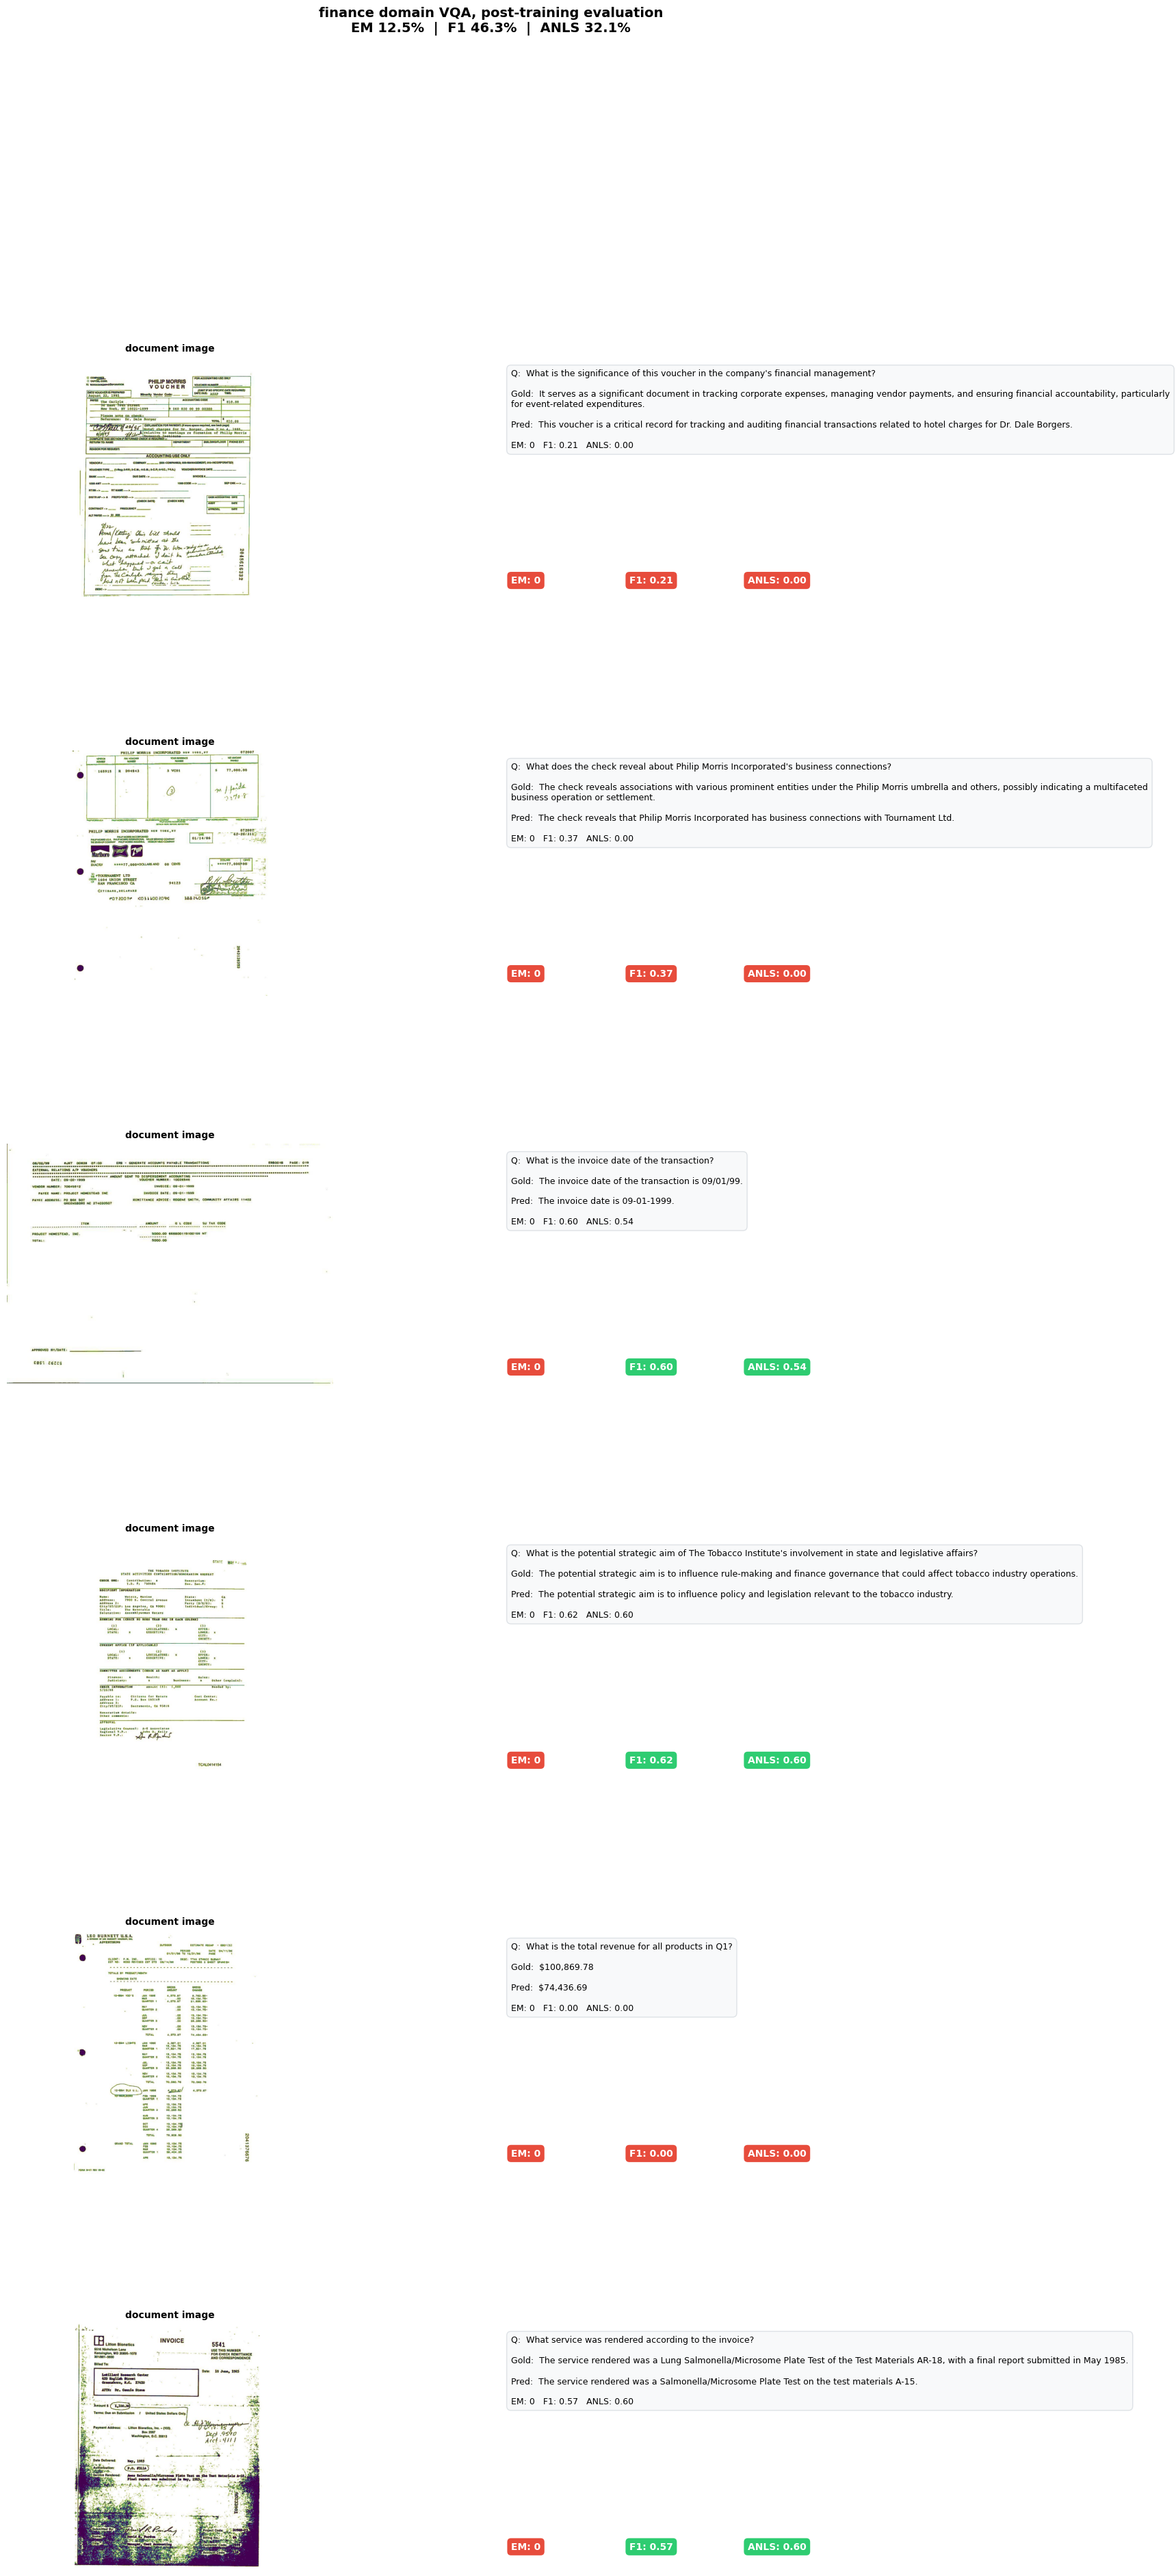

figure saved → /content/finance_vqa_eval.png


In [ ]:
vis = results[:VIS_SAMPLES]
fig = plt.figure(figsize=(20, 7 * len(vis)))
gs  = gridspec.GridSpec(len(vis), 2, width_ratios=[1, 1.4], hspace=0.6, wspace=0.3)

for row, r in enumerate(vis):

    ax_img = fig.add_subplot(gs[row, 0])
    ax_img.imshow(r["image"])
    ax_img.axis("off")
    ax_img.set_title("document image", fontsize=10, fontweight="bold", pad=6)


    ax_txt = fig.add_subplot(gs[row, 1])
    ax_txt.axis("off")

    em_colour   = "#2ecc71" if r["em"]   == 1    else "#e74c3c"
    f1_colour   = "#2ecc71" if r["f1"]   >= 0.5  else "#e74c3c"
    anls_colour = "#2ecc71" if r["anls"] >= 0.5  else "#e74c3c"

    text_block = (
        f"Q:  {r['question']}\n\n"
        f"Gold:  {r['gold']}\n\n"
        f"Pred:  {r['pred']}\n\n"
        f"EM: {r['em']}   F1: {r['f1']:.2f}   ANLS: {r['anls']:.2f}"
    )
    ax_txt.text(
        0.02, 0.95, text_block,
        va="top", ha="left", transform=ax_txt.transAxes,
        fontsize=9, wrap=True,
        bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="#dee2e6"),
    )


    for xi, (label, val, colour) in enumerate([
        ("EM",   f"{r['em']}",        em_colour),
        ("F1",   f"{r['f1']:.2f}",    f1_colour),
        ("ANLS", f"{r['anls']:.2f}",  anls_colour),
    ]):
        ax_txt.text(
            0.02 + xi * 0.22, 0.08, f"{label}: {val}",
            transform=ax_txt.transAxes,
            fontsize=10, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.4", fc=colour, ec="none"),
        )

plt.suptitle(
    f"finance domain VQA, post-training evaluation\n"
    f"EM {avg_em*100:.1f}%  |  F1 {avg_f1*100:.1f}%  |  ANLS {avg_anls*100:.1f}%",
    fontsize=14, fontweight="bold", y=1.002,
)
plt.savefig("/content/finance_vqa_eval.png", dpi=120, bbox_inches="tight")
plt.show()
print("figure saved → /content/finance_vqa_eval.png")

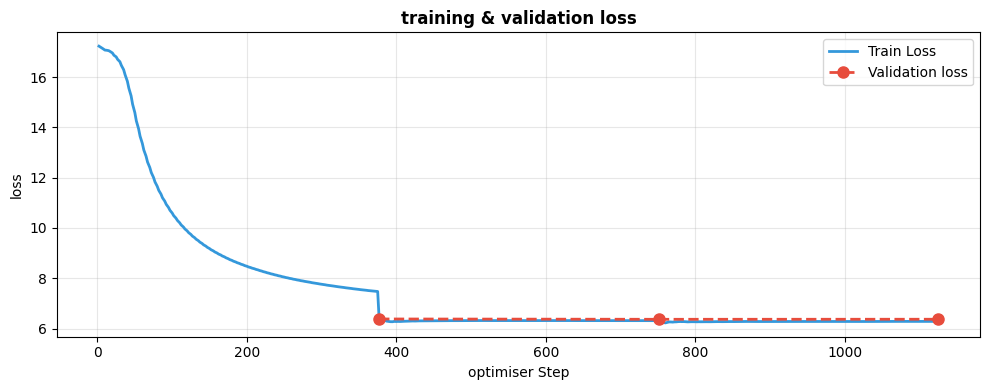

loss curve saved → /content/finance_vqa_loss.png


In [ ]:
if train_losses:
    fig2, ax = plt.subplots(figsize=(10, 4))
    ax.plot(step_log, train_losses, label="Train Loss", color="#3498db", linewidth=2)
    if val_losses:
        ep_steps = [step_log[min(i * (len(step_log) // NUM_EPOCHS),
                                 len(step_log)-1)]
                    for i in range(1, NUM_EPOCHS + 1)]
        ax.plot(ep_steps[:len(val_losses)], val_losses,
                "o--", label="Validation loss", color="#e74c3c", linewidth=2, markersize=8)
    ax.set_xlabel("optimiser Step"); ax.set_ylabel("loss")
    ax.set_title("training & validation loss", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/finance_vqa_loss.png", dpi=120)
    plt.show()
    print("loss curve saved → /content/finance_vqa_loss.png")